In [85]:
# import nacessary library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [86]:
df=pd.read_csv('Resume_DataSet.csv')
df.shape

(962, 2)

### Basic

In [87]:
# Group by category and take first 20 items
# df = df.groupby("Category").head(10)



In [88]:
df.shape

(962, 2)

In [89]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


In [91]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [92]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [93]:
df.Category.value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

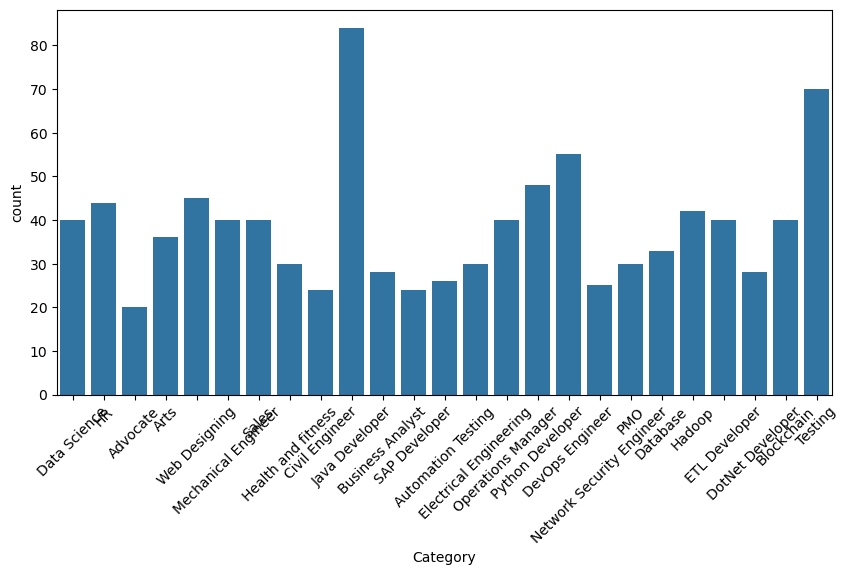

In [94]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Category'])
plt.xticks(rotation=45)
plt.show()

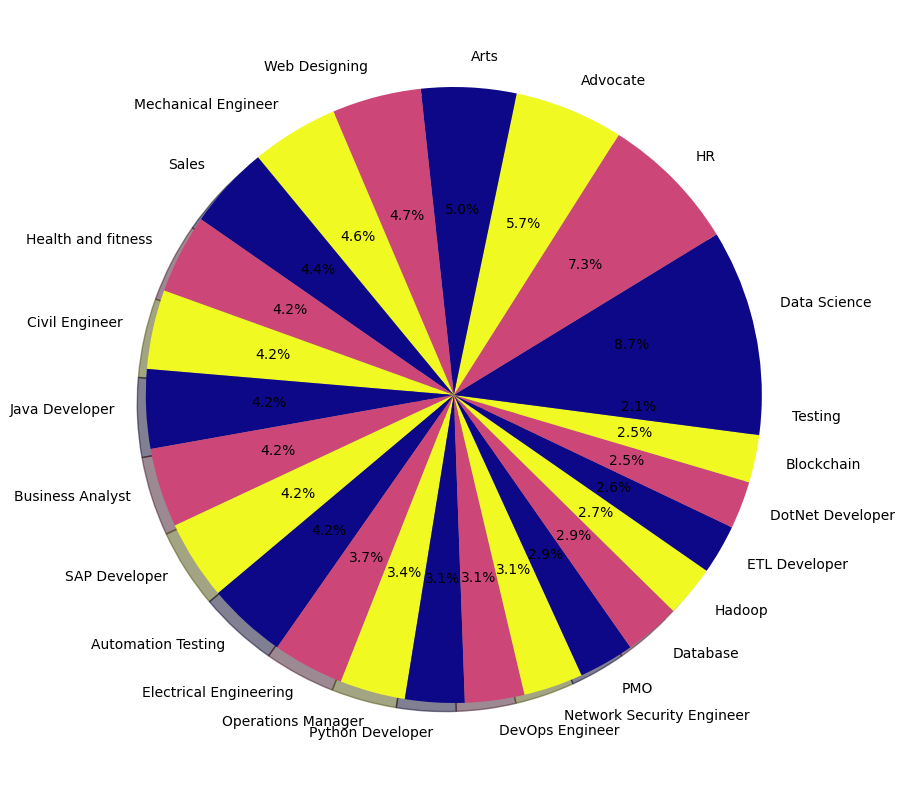

In [95]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

In [96]:
 df['Resume'][7]

'Education Details \r\n B.Tech   Rayat and Bahra Institute of Engineering and Biotechnology\r\nData Science \r\n\r\nData Science\r\nSkill Details \r\nNumpy- Exprience - Less than 1 year months\r\nMachine Learning- Exprience - Less than 1 year months\r\nTensorflow- Exprience - Less than 1 year months\r\nScikit- Exprience - Less than 1 year months\r\nPython- Exprience - Less than 1 year months\r\nGCP- Exprience - Less than 1 year months\r\nPandas- Exprience - Less than 1 year months\r\nNeural Network- Exprience - Less than 1 year monthsCompany Details \r\ncompany - Wipro\r\ndescription - Bhawana Aggarwal\r\nE-Mail:bhawana.chd@gmail.com\r\nPhone: 09876971076\r\nVVersatile, high-energy professional targeting challenging assignments in Machine\r\nPROFILE SUMMARY\r\nâ\x96ª An IT professional with knowledge and experience of 2 years in Wipro Technologies in Machine\r\nLearning, Deep Learning, Data Science, Python, Software Development.\r\nâ\x96ª Skilled in managing end-to-end development and 

### Data Clining

In [97]:
# import re
# df['Resume'] = df['Resume'].str.lower().apply(lambda x: re.sub(r'[^a-z\s]', '', x))

In [98]:
import re
def cleanResume(txt):
    df['Resume'] = df['Resume'].str.lower().apply(lambda x: re.sub(r'[^a-z\s]', '', x))
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', txt)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) 
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText
    
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

In [99]:
df['Resume'][0]

'Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in accelerating the

In [100]:
# Resume break in token
import nltk
nltk.download('punkt')
df['Tokens'] = df['Resume'].apply(nltk.word_tokenize)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cnd15\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [101]:
df.head()

,Category,Resume,Tokens
0,Data Science,Skills Programming Languages Python pandas num...,"[Skills, Programming, Languages, Python, panda..."
1,Data Science,Education Details May 2013 to May 2017 B E UIT...,"[Education, Details, May, 2013, to, May, 2017,..."
2,Data Science,Areas of Interest Deep Learning Control System...,"[Areas, of, Interest, Deep, Learning, Control,..."
3,Data Science,Skills R Python SAP HANA Tableau SAP HANA SQL ...,"[Skills, R, Python, SAP, HANA, Tableau, SAP, H..."
4,Data Science,Education Details MCA YMCAUST Faridabad Haryan...,"[Education, Details, MCA, YMCAUST, Faridabad, ..."


In [102]:
# Remove Stop word
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['Tokens'] = df['Tokens'].apply(lambda x: [word for word in x if word not in stop_words])

In [103]:
df['Tokens'][7]

['Education',
 'Details',
 'B',
 'Tech',
 'Rayat',
 'Bahra',
 'Institute',
 'Engineering',
 'Biotechnology',
 'Data',
 'Science',
 'Data',
 'Science',
 'Skill',
 'Details',
 'Numpy',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'Machine',
 'Learning',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'Tensorflow',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'Scikit',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'Python',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'GCP',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'Pandas',
 'Exprience',
 'Less',
 '1',
 'year',
 'months',
 'Neural',
 'Network',
 'Exprience',
 'Less',
 '1',
 'year',
 'monthsCompany',
 'Details',
 'company',
 'Wipro',
 'description',
 'Bhawana',
 'Aggarwal',
 'E',
 'Mail',
 'bhawana',
 'chd',
 'gmail',
 'com',
 'Phone',
 '09876971076',
 'VVersatile',
 'high',
 'energy',
 'professional',
 'targeting',
 'challenging',
 'assignments',
 'Machine',
 'PROFILE',
 'SUMMARY',
 'An',
 'IT',
 'profession

In [104]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
df['Tokens'] = df['Tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cnd15\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [105]:
df.head()

,Category,Resume,Tokens
0,Data Science,Skills Programming Languages Python pandas num...,"[Skills, Programming, Languages, Python, panda..."
1,Data Science,Education Details May 2013 to May 2017 B E UIT...,"[Education, Details, May, 2013, May, 2017, B, ..."
2,Data Science,Areas of Interest Deep Learning Control System...,"[Areas, Interest, Deep, Learning, Control, Sys..."
3,Data Science,Skills R Python SAP HANA Tableau SAP HANA SQL ...,"[Skills, R, Python, SAP, HANA, Tableau, SAP, H..."
4,Data Science,Education Details MCA YMCAUST Faridabad Haryan...,"[Education, Details, MCA, YMCAUST, Faridabad, ..."


In [106]:
df['Text_joined'] = df['Tokens'].apply(lambda tokens: " ".join(tokens))

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(df['Text_joined'])
X  = vectorizer.transform(df['Text_joined'])


In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category']= le.fit_transform(df['Category'])
y=df['category']

In [108]:
values=df.Category.unique()
keys=[ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23]

my_dict=dict(zip(keys,values))
my_dict

{6: 'Data Science',
 12: 'HR',
 0: 'Advocate',
 1: 'Arts',
 24: 'Web Designing',
 16: 'Mechanical Engineer',
 22: 'Sales',
 14: 'Health and fitness',
 5: 'Civil Engineer',
 15: 'Java Developer',
 4: 'Business Analyst',
 21: 'SAP Developer',
 2: 'Automation Testing',
 11: 'Electrical Engineering',
 18: 'Operations Manager',
 20: 'Python Developer',
 8: 'DevOps Engineer',
 17: 'Network Security Engineer',
 19: 'PMO',
 7: 'Database',
 13: 'Hadoop',
 10: 'ETL Developer',
 9: 'DotNet Developer',
 3: 'Blockchain',
 23: 'Testing'}

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00        12
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.00        15
          16       1.00      1.00      1.00         8
          17       1.00    

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure that X_train and X_test are dense if they are sparse
X_train = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# 1. Train KNeighborsClassifier
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 0.9845
Confusion Matrix:
[[ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  

In [112]:

# 2. Train SVC
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")


SVC Results:
Accuracy: 0.9948
Confusion Matrix:
[[ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  0  0  0  0  0  0 

In [113]:
# 3. Train RandomForestClassifier
rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


RandomForestClassifier Results:
Accuracy: 0.9845
Confusion Matrix:
[[ 1  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0

### Save File

In [114]:
import pickle
pickle.dump(vectorizer,open('tfidf.pkl','wb'))
pickle.dump(svc_model, open('clf.pkl', 'wb'))

In [115]:
import pickle

with open("clf.pkl", "rb") as f:
    clf = pickle.load(f)

In [116]:
pickle.dump(svc_model, open('model.pkl', 'wb'))

In [117]:
import pickle

with open("model.pkl", "rb") as f:
    clf = pickle.load(f)

In [118]:
import joblib

clf = joblib.load("model.pkl")

In [119]:
pickle.dump(rf_model, open('rf_model.pkl', 'wb'))

In [120]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean CV score:", scores.mean())


Cross-validation scores: [0.97927461 1.         1.         1.         1.        ]
Mean CV score: 0.9958549222797928


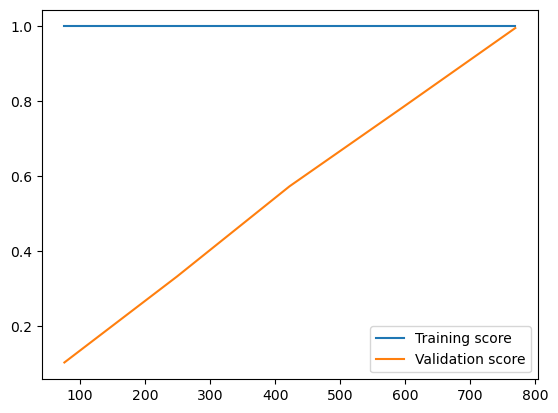

In [121]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(rf_model, X, y, cv=5)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation score")
plt.legend()
plt.show()
